# PARA ESTE PROYECTO SOLO USAREMOS EL DF DE EGRESOS

# CARGA DE DATOS

In [20]:
import pandas as pd
import numpy as np
import missingno as sms
import seaborn as sns
import matplotlib.pyplot as plt

#pruebas estadisticas

from scipy import stats

In [2]:
df= pd.read_csv('../datos/ssa_egresos_2023/Registros/Egresos.txt',sep='|',encoding='utf-8-sig',low_memory=False)

In [73]:
df.sample(1).T

,1644669
CLUES,VZSSA001150
EGRESO,2023-12-13
INGRE,2023-12-12
DIAS_ESTA,1
TUHPSIQ,-1
SERVHC,-1
SERVHP,-1
CVEEDAD,4.0
EDAD,8.0
NACIOEN,8


In [4]:
df.columns.to_list()

['ID',
 'CLUES',
 'EGRESO',
 'INGRE',
 'DIAS_ESTA',
 'TUHPSIQ',
 'SERVHC',
 'SERVHP',
 'CVEEDAD',
 'EDAD',
 'NACIOEN',
 'SEXO',
 'PESO',
 'TALLA',
 'DERHAB',
 'ENTIDAD',
 'MUNIC',
 'LOC',
 'INDIGENA',
 'HABLA_LENGUA',
 'LENGUA_INDIGENA',
 'TIPSERV',
 'SERVICIOINGRE',
 'SERVICIO02',
 'SERVICIO03',
 'SERVICIOEGRE',
 'PROCED',
 'CLUESPROCED',
 'MOTEGRE',
 'CLUESREFERIDO',
 'DIAG_INI',
 'AFECPRIN',
 'VEZ',
 'INFEC',
 'CAUSAEXT',
 'MES_ESTADISTICO',
 'ESTADO_CONYUGAL_KEY',
 'MP',
 'GESTAS',
 'PARTOS',
 'ABORTOS',
 'HAYPROD',
 'TIPATEN',
 'GESTAC',
 'PRODUCTO',
 'TIPNACI',
 'PLANFAM',
 'CESAREAS',
 'TOTAL_PRODUCTOS']

## ELIMINAR COLUMNAS QUE NO APORTAN

YA QUE ALGUNAS COLUMANS SON PARA EMBARAZOS LAS ELIMINARE 

In [ ]:
df.drop(['GESTAS', 'PARTOS', 'ABORTOS', 'CESAREAS','HAYPROD', 'PRODUCTO', 'TIPNACI', 'TOTAL_PRODUCTOS','TIPATEN', 'GESTAC','MP', 'PLANFAM','ID'],axis=1,inplace=True)

primero veremos que tan mal estamos de nulos, quizas podemos eliminar alguna de primeras y borrar filas

In [6]:
pc_nulos = round(df.isna().sum()/len(df),2)
df.drop(pc_nulos.loc[pc_nulos>0.90].index.to_list(),axis=1,inplace=True)

leyendo la documentacion vemos que algunos valores son para nulos entonces aplicamos la transformacion

In [14]:
df['SEXO'] = df['SEXO'].replace({0: np.nan, 9: np.nan})
df['DERHAB'] = df['DERHAB'].replace({'0': np.nan})
df['PESO'] = df['PESO'].replace({999.0: np.nan})
df['TALLA'] = df['TALLA'].replace({999: np.nan})
df['PROCED'] = df['PROCED'].replace({9: np.nan})
df['VEZ'] = df['VEZ'].replace({9: np.nan})
df['CVEEDAD'] = df['CVEEDAD'].replace({9: np.nan})
df['EDAD'] = df['EDAD'].replace({999: np.nan})
df['INFEC'] = df['INFEC'].replace({9: np.nan})  # deja el 8 aparte por ahora

# VISTA RAPIDA DE NULOS CON MISSINGNO

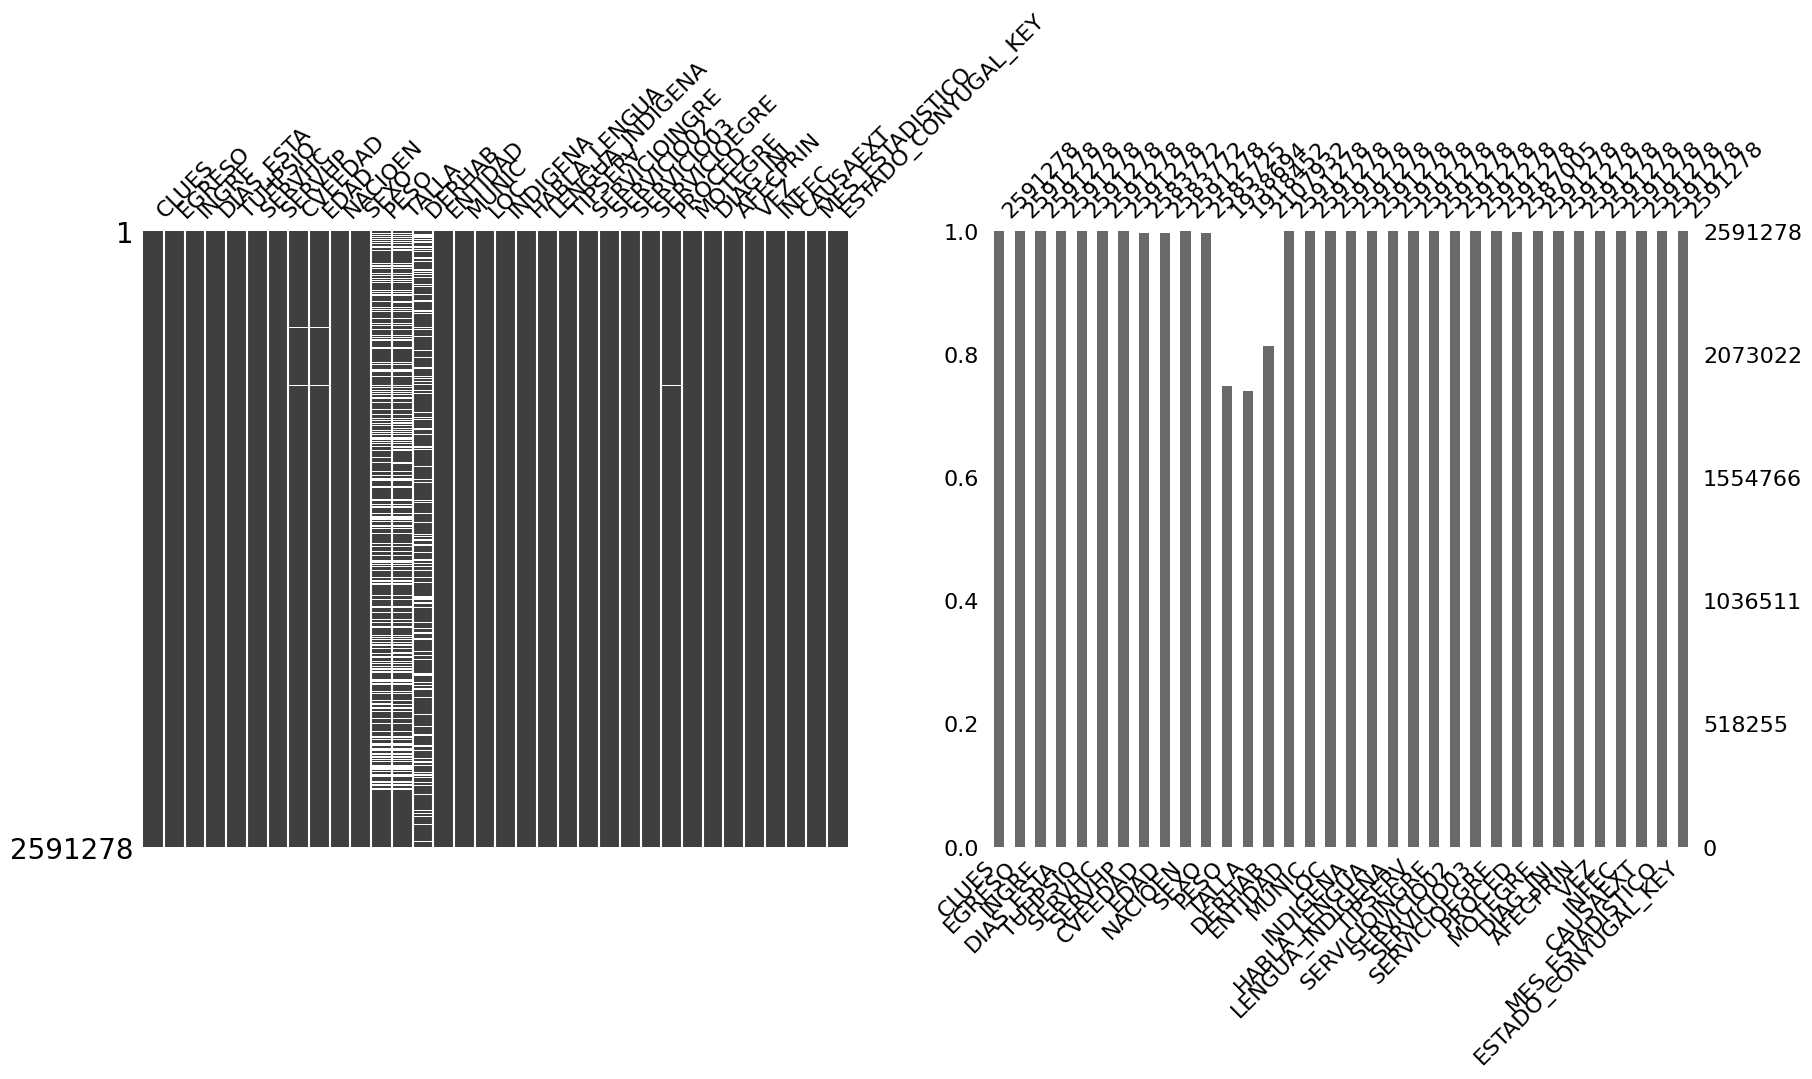

In [15]:
fig,ax = plt.subplots(1,2,figsize = (20,8))
sms.matrix(df,sparkline=False,ax=ax[0])
sms.bar(df,ax=ax[1])
plt.tight_layout
plt.show()

muchisimos nulos en talla y peso

In [19]:
pc_nulos = round(df.isna().sum()/len(df),4)
pc_nulos

CLUES                  0.0000
EGRESO                 0.0000
INGRE                  0.0000
DIAS_ESTA              0.0000
TUHPSIQ                0.0000
SERVHC                 0.0000
SERVHP                 0.0000
CVEEDAD                0.0029
EDAD                   0.0029
NACIOEN                0.0000
SEXO                   0.0021
PESO                   0.2518
TALLA                  0.2597
DERHAB                 0.1865
ENTIDAD                0.0000
MUNIC                  0.0000
LOC                    0.0000
INDIGENA               0.0000
HABLA_LENGUA           0.0000
LENGUA_INDIGENA        0.0000
TIPSERV                0.0000
SERVICIOINGRE          0.0000
SERVICIO02             0.0000
SERVICIO03             0.0000
SERVICIOEGRE           0.0000
PROCED                 0.0016
MOTEGRE                0.0000
DIAG_INI               0.0000
AFECPRIN               0.0000
VEZ                    0.0000
INFEC                  0.0000
CAUSAEXT               0.0000
MES_ESTADISTICO        0.0000
ESTADO_CON

In [27]:
#funcion crammers v

def crammers_v(crosstab):
    chi2,p,dof,expect = stats.chi2_contingency(crosstab)
    n = crosstab.sum().sum()
    r,c = crosstab.shape
    if min(r-1,c-1) == 0:
        v=0.0
    else:
        v = np.sqrt(chi2/(n*(min(r-1,c-1))))
    return v , p 

creamos las nuevas columnas para comparar

In [23]:
df['PESO_nulo'] = df['PESO'].isnull().astype(int)
df['TALLA_nulo'] = df['TALLA'].isnull().astype(int)
df['DERHAB_nulo'] = df['DERHAB'].isnull().astype(int)

haremos un test chi2 con crammer para ver el effect size y saber en que variables si hay un cambio notorio y hacer alguna hipotesis

In [36]:
resultados = []

columns_nul = ['PESO_nulo','TALLA_nulo','DERHAB_nulo']
for nul in columns_nul:
    for col in df.columns:
        if nul!=col and col not in columns_nul:
            table = pd.crosstab(df[nul],df[col])
            v,p = crammers_v(table)
            resultados.append({
                'Variable_Nula': nul,
                'Variable_Comparada': col,
                'V_Cramer': v,
                'Valor_p': p
            })
        
df_resultados_nulos = pd.DataFrame(resultados)

In [74]:
variables_peso_nulos = df_resultados_nulos[df_resultados_nulos['Variable_Nula']=='PESO_nulo'].sort_values(ascending=False,by='V_Cramer').head(20)
variables_talla_nulos =df_resultados_nulos[df_resultados_nulos['Variable_Nula']=='TALLA_nulo'].sort_values(ascending=False,by='V_Cramer').head(20)
variables_derhab_nulos = df_resultados_nulos[df_resultados_nulos['Variable_Nula']=='DERHAB_nulo'].sort_values(ascending=False,by='V_Cramer').head(20)

matriz_nulos_num = df.corr(numeric_only=True,method='spearman')[columns_nul]


In [ ]:
variables_derhab_nulos

,Variable_Nula,Variable_Comparada,V_Cramer,Valor_p
68,DERHAB_nulo,CLUES,0.641321,0.0
82,DERHAB_nulo,ENTIDAD,0.242773,0.0
83,DERHAB_nulo,MUNIC,0.221352,0.0
96,DERHAB_nulo,AFECPRIN,0.172338,0.0
95,DERHAB_nulo,DIAG_INI,0.172075,0.0
89,DERHAB_nulo,SERVICIOINGRE,0.152596,0.0
92,DERHAB_nulo,SERVICIOEGRE,0.150998,0.0
101,DERHAB_nulo,ESTADO_CONYUGAL_KEY,0.149525,0.0
90,DERHAB_nulo,SERVICIO02,0.147180,0.0
79,DERHAB_nulo,PESO,0.108743,0.0


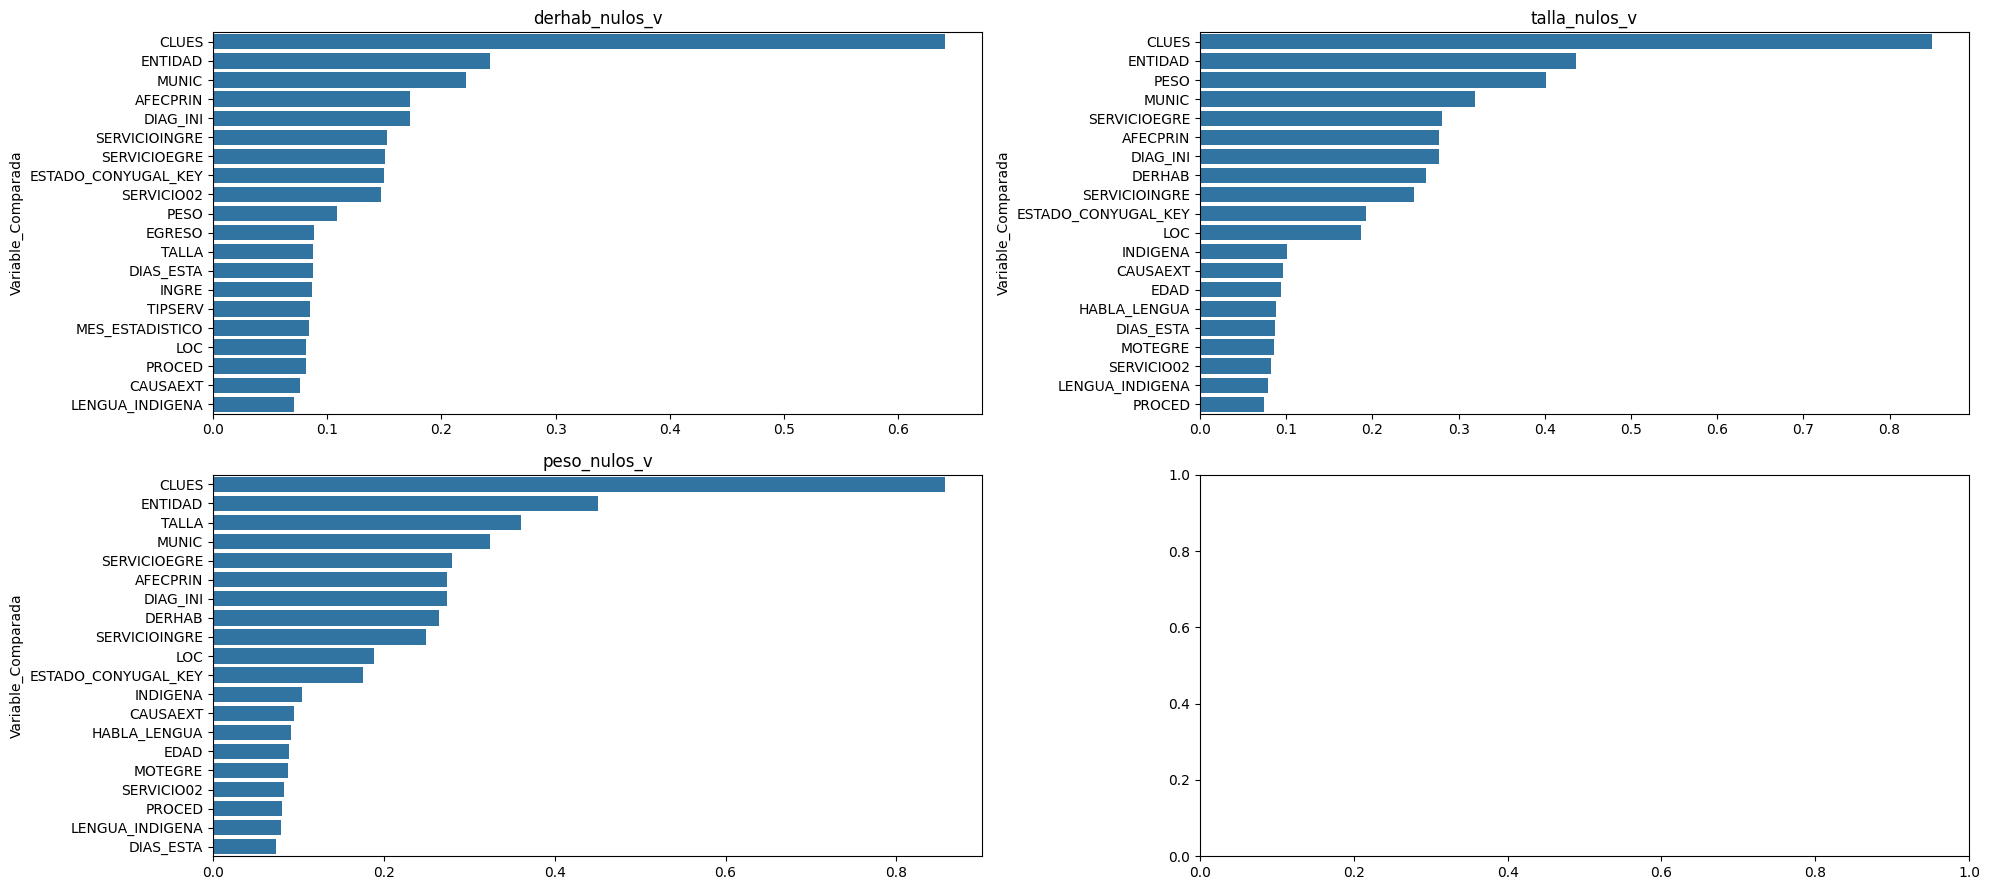

In [70]:
fig,ax.flat = plt.subplots(2,2,figsize = (20,9))
ax[0].set_title('derhab_nulos_v')
sns.barplot(x=variables_derhab_nulos['V_Cramer'].values,y=variables_derhab_nulos['Variable_Comparada'],ax=ax[0])
ax[1].set_title('talla_nulos_v')
sns.barplot(x=variables_talla_nulos['V_Cramer'].values,y=variables_talla_nulos['Variable_Comparada'],ax=ax[1])
ax[2].set_title('peso_nulos_v')
sns.barplot(x=variables_peso_nulos['V_Cramer'].values,y=variables_peso_nulos['Variable_Comparada'],ax=ax[2])

plt.tight_layout()
plt.show()

<Axes: >

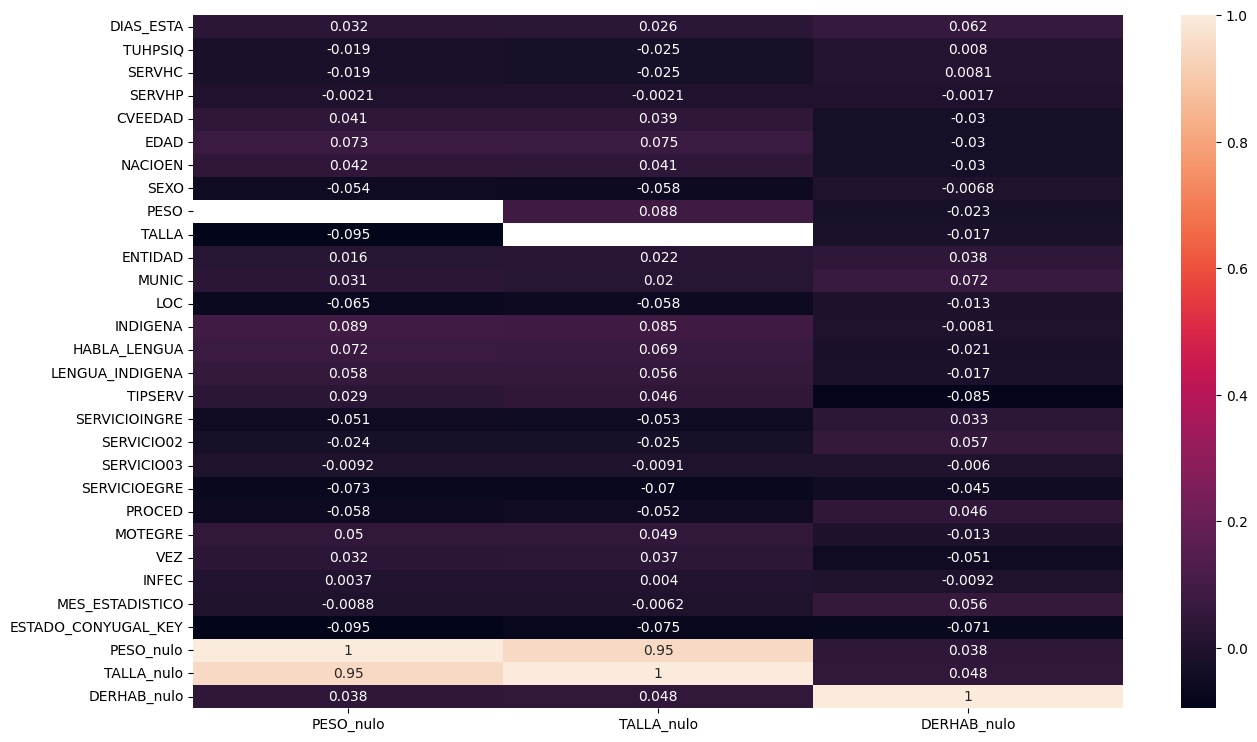

In [75]:
plt.figure(figsize=(15,9))
sns.heatmap(matriz_nulos_num,annot=True)

como podemos ver la falta de valores es institucional o esa es mi toeria, algunos hospitales no capturas estos datos como otros sin emabrgo hay una relacion menos fuerte en 

# haremos un analizis rapido

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2591278 entries, 0 to 2591277
Data columns (total 34 columns):
 #   Column               Dtype  
---  ------               -----  
 0   CLUES                object 
 1   EGRESO               object 
 2   INGRE                object 
 3   DIAS_ESTA            int64  
 4   TUHPSIQ              int64  
 5   SERVHC               int64  
 6   SERVHP               int64  
 7   CVEEDAD              int64  
 8   EDAD                 int64  
 9   NACIOEN              int64  
 10  SEXO                 int64  
 11  PESO                 float64
 12  TALLA                int64  
 13  DERHAB               object 
 14  ENTIDAD              int64  
 15  MUNIC                int64  
 16  LOC                  int64  
 17  INDIGENA             int64  
 18  HABLA_LENGUA         int64  
 19  LENGUA_INDIGENA      int64  
 20  TIPSERV              int64  
 21  SERVICIOINGRE        int64  
 22  SERVICIO02           int64  
 23  SERVICIO03           int64  
 24

In [ ]:
col_num = df.select_dtypes(include=np.number).columns.to_list()
col_cat= df.select_dtypes(exclude=np.number).columns.to_list()

In [13]:
df[col_num].describe().T

,count,mean,std,min,25%,50%,75%,max
DIAS_ESTA,2591278.0,3.773022,52.403086,0.0,1.0,2.0,3.0,15000.0
TUHPSIQ,2591278.0,-0.986087,0.166717,-1.0,-1.0,-1.0,-1.0,3.0
SERVHC,2591278.0,-0.979037,0.254935,-1.0,-1.0,-1.0,-1.0,9.0
SERVHP,2591278.0,-0.999961,0.011233,-1.0,-1.0,-1.0,-1.0,9.0
CVEEDAD,2591278.0,4.866108,0.634104,2.0,5.0,5.0,5.0,9.0
EDAD,2591278.0,37.362539,56.029178,1.0,20.0,30.0,50.0,999.0
NACIOEN,2591278.0,7.624896,1.557592,1.0,8.0,8.0,8.0,8.0
SEXO,2591278.0,1.664527,0.476698,0.0,1.0,2.0,2.0,3.0
PESO,2591278.0,298.164377,407.217728,0.5,59.0,72.0,999.0,999.0
TALLA,2591278.0,367.099269,375.252257,15.0,150.0,160.0,999.0,999.0


In [71]:
df[col_cat].describe().T

,count,unique,top,freq
CLUES,2591278,900,TCSSA001064,61366
EGRESO,2591278,365,2023-10-06,9107
INGRE,2591278,759,2023-10-02,9016
DERHAB,2107932,12,1,869752
DIAG_INI,2591278,7871,O809,286908
AFECPRIN,2591278,7953,O809,280519
CAUSAEXT,2591278,2110,8888,2373826
